In [1]:
import numpy as np
import pandas as pd
import re
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
from scipy.stats import gaussian_kde
from scipy.spatial.distance import pdist
from scipy.spatial.distance import cdist
from sklearn.metrics import silhouette_score, silhouette_samples

from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D
from adjustText import adjust_text

In [2]:
logits_paths = {
    'lambda0p0': 'E3_logprobs/logprobs_lambda0p0.npy',
    'lambda0p001': 'E3_logprobs/logprobs_lambda0p001.npy',
    'lambda0p01': 'E3_logprobs/logprobs_lambda0p01.npy',
    'lambda0p1': 'E3_logprobs/logprobs_lambda0p1.npy',
    'lambda1p0': 'E3_logprobs/logprobs_lambda1p0.npy',
}

model_names = ['lambda0p0', 'lambda0p001', 'lambda0p01', 'lambda0p1', 'lambda1p0']

In [3]:
X_dict = {
    'lambda0p0': np.load(logits_paths['lambda0p0']),
    'lambda0p001': np.load(logits_paths['lambda0p001']),
    'lambda0p01': np.load(logits_paths['lambda0p01']),
    'lambda0p1': np.load(logits_paths['lambda0p1']),
    'lambda1p0': np.load(logits_paths['lambda1p0']),
}

X_all = np.vstack([X_dict['lambda0p0'], X_dict['lambda0p001'], X_dict['lambda0p01'], X_dict['lambda0p1'], X_dict['lambda1p0']])
print(X_all.shape)

scaler = StandardScaler()
scaler.fit(X_all)

(5000, 50304)


StandardScaler()

In [4]:
X_pca_dict = {}
n_components = 50
for model_name in model_names:
    X = X_dict[model_name]
    X_scaled = scaler.transform(X)
    print(X_scaled.shape)
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    X_pca_dict[model_name] = {"X_pca": X_pca, "pca": pca}
    print(f"Model {model_name} explained variance ratio (first {n_components} PCs):")
    print(pca.explained_variance_ratio_.sum())
    print()

(1000, 50304)
Model lambda0p0 explained variance ratio (first 50 PCs):
0.9510047

(1000, 50304)
Model lambda0p001 explained variance ratio (first 50 PCs):
0.9668674

(1000, 50304)
Model lambda0p01 explained variance ratio (first 50 PCs):
0.98057395

(1000, 50304)
Model lambda0p1 explained variance ratio (first 50 PCs):
0.9709509

(1000, 50304)
Model lambda1p0 explained variance ratio (first 50 PCs):
0.97975403



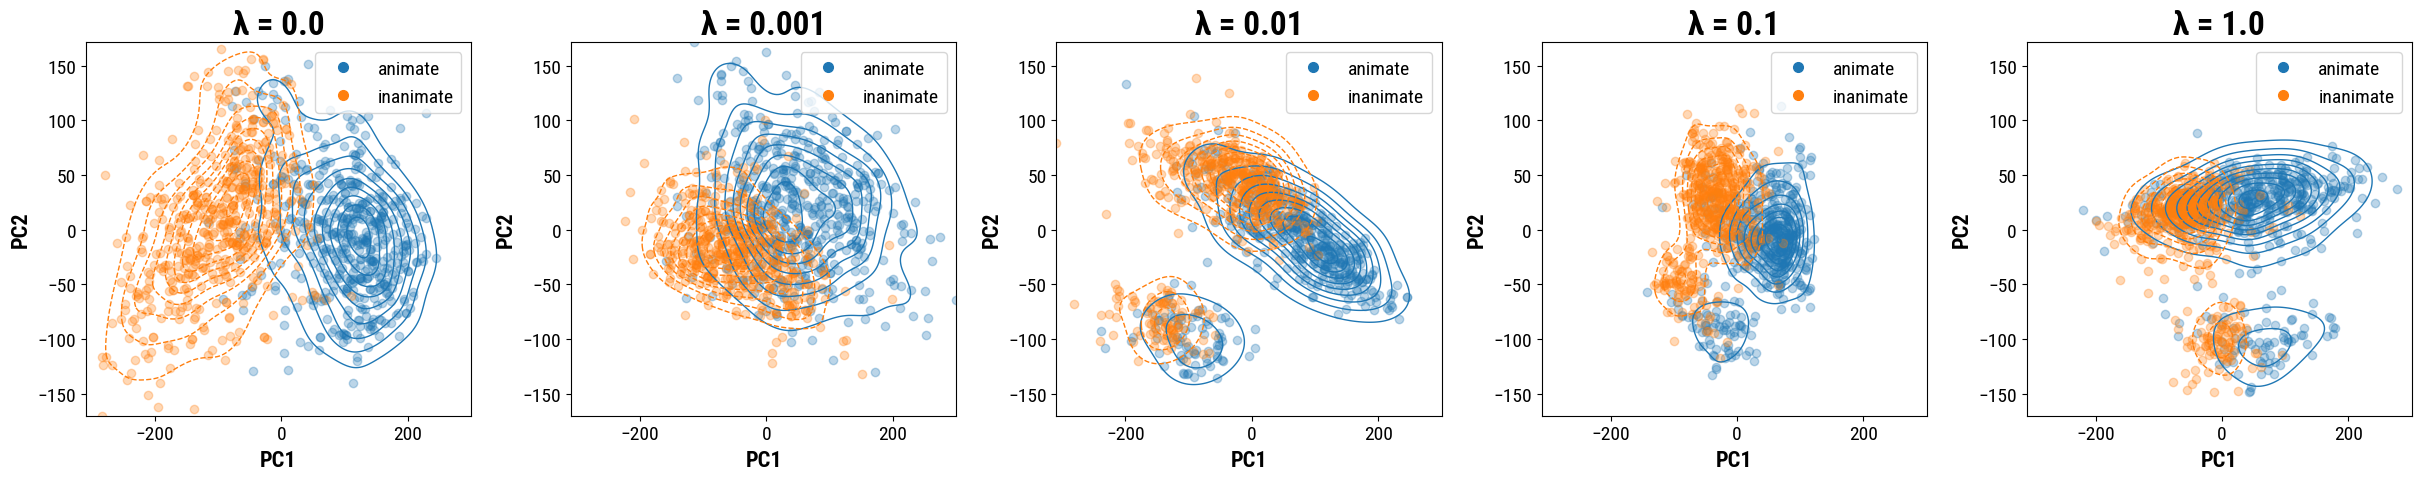

In [5]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 24,
    'axes.labelweight': 'bold',
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "font.family": "Roboto Condensed",
    "mathtext.fontset": "custom",        
    "mathtext.rm": "Roboto Condensed",  
    "mathtext.it": "Roboto Condensed:italic",
    "mathtext.bf": "Roboto Condensed:bold",
})

panel_titles = {
    'lambda0p0': "λ = 0.0",
    'lambda0p001': "λ = 0.001",
    'lambda0p01': "λ = 0.01",
    'lambda0p1': "λ = 0.1",
    'lambda1p0': "λ = 1.0"
}

#### plotting

n_models = len(model_names)
fig, axes = plt.subplots(1, n_models, figsize=(4.9 * n_models, 5.1), squeeze=False)

pc1_vals = []
pc2_vals = []

for model_name in model_names:
    X_pca = X_pca_dict[model_name]["X_pca"]
    pc1_vals.append(X_pca[:, 0])
    pc2_vals.append(X_pca[:, 1])

pc1_all = np.concatenate(pc1_vals)
pc2_all = np.concatenate(pc2_vals)

pc1_min, pc1_max = pc1_all.min(), pc1_all.max()
pc2_min, pc2_max = pc2_all.min(), pc2_all.max()

xx, yy = np.mgrid[pc1_min:pc1_max:200j, pc2_min:pc2_max:200j]

# Plot each model panel
for ax, model_name in zip(axes[0], model_names):
    X_pca = X_pca_dict[model_name]["X_pca"]

    pca_ani = X_pca[:500, :]
    pca_inani = X_pca[500:, :]

    # First 500: Animate
    pc1_ani = X_pca[:500, 0]
    pc2_ani = X_pca[:500, 1]

    # Second 500: Inanimate
    pc1_inani = X_pca[500:, 0]
    pc2_inani = X_pca[500:, 1]

    # scatter points
    ani_sc = ax.scatter(pc1_ani, pc2_ani, alpha=0.3, label="animate")
    inani_sc = ax.scatter(pc1_inani, pc2_inani, alpha=0.3, label="inanimate")

    # density contours (per category)  
    ani_kde = gaussian_kde(np.vstack([pc1_ani, pc2_ani]))
    zz_ani = ani_kde(np.vstack([xx.ravel(), yy.ravel()]))
    zz_ani = zz_ani.reshape(xx.shape)
    c_ani = tuple(ani_sc.get_facecolor()[0])  
    c_ani = (c_ani[0], c_ani[1], c_ani[2], 0.3)  
    ax.contour(xx, yy, zz_ani, levels=10, colors=[c_ani], linewidths=1.0, alpha=1.0)

    inani_kde = gaussian_kde(np.vstack([pc1_inani, pc2_inani]))
    zz_inani = inani_kde(np.vstack([xx.ravel(), yy.ravel()]))
    zz_inani = zz_inani.reshape(xx.shape)
    c_inani = tuple(inani_sc.get_facecolor()[0])
    c_inani = (c_inani[0], c_inani[1], c_inani[2], 0.3)
    ax.contour(xx, yy, zz_inani, levels=10, colors=[c_inani], linestyles="dashed", linewidths=1.0, alpha=1.0)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(panel_titles[model_name])

    ax.set_xlim(pc1_min, pc1_max)
    ax.set_ylim(pc2_min, pc2_max)

# Legends
legend_ani = Line2D([0], [0], marker='o', markersize=7,
                    linestyle='none', color="#1f77b4", alpha=1.0,
                    label="animate")

legend_inani = Line2D([0], [0], marker='o', markersize=7,
                      linestyle='none', color="#ff7f0e", alpha=1.0,
                      label="inanimate")

for ax in axes[0]:
    leg = ax.legend(
        handles=[legend_ani, legend_inani],
        loc="upper right"
    )

plt.tight_layout()
# plt.savefig("plots/PCA.pdf", bbox_inches="tight", pad_inches=0.05)
# plt.savefig("plots/PCA.png", bbox_inches="tight", pad_inches=0.05)
plt.show()


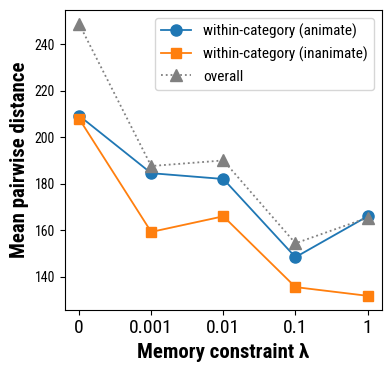

In [6]:

def cluster_compactness(pca):

    # All pairwise distances
    pairwise_dists = pdist(pca, 'euclidean') 

    n_pw = pairwise_dists.shape[0]  
    std_pw = pairwise_dists.std(ddof=1)
    se_pw = std_pw / np.sqrt(n_pw)

    return {
        "mean_dist": float(pairwise_dists.mean()),        
        "median_dist": float(np.median(pairwise_dists)),
        "std_dist": float(std_pw),
        "se_dist": float(se_pw),
        "n": int(pca.shape[0]),
        "n_pairwise": int(n_pw)
    }


plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 15,
    'axes.labelweight': 'bold',
    "axes.labelsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "font.family": "Roboto Condensed"
})

lambda_ordered_names = [
    "lambda0p0",
    "lambda0p001",
    "lambda0p01",
    "lambda0p1",
    "lambda1p0",
]

# lambda_labels = ["λ=0", "λ=0.001", "λ=0.01", "λ=0.1", "λ=1"]
lambda_labels = ["0", "0.001", "0.01", "0.1", "1"]

ani_values, inani_values = [], []
ani_se_values, inani_se_values = [], []
overall_values, overall_se_values = [], []
category_dist_values, category_se_values = [], []  

for model_name in lambda_ordered_names:
    X_pca = X_pca_dict[model_name]["X_pca"]
    pca_ani = X_pca[:500, :]
    pca_inani = X_pca[500:, :]

    ani_stats = cluster_compactness(pca_ani)
    inani_stats = cluster_compactness(pca_inani)
    overall_stats = cluster_compactness(X_pca)

    ani_values.append(ani_stats['mean_dist'])
    inani_values.append(inani_stats['mean_dist'])
    ani_se_values.append(ani_stats['se_dist'])
    inani_se_values.append(inani_stats['se_dist'])

    overall_values.append(overall_stats['mean_dist'])
    overall_se_values.append(overall_stats['se_dist'])

y_lower = (
    [m - s for m, s in zip(ani_values, ani_se_values)] +
    [m - s for m, s in zip(inani_values, inani_se_values)] +
    [m - s for m, s in zip(overall_values, overall_se_values)]
)
y_upper = (
    [m + s for m, s in zip(ani_values, ani_se_values)] +
    [m + s for m, s in zip(inani_values, inani_se_values)] +
    [m + s for m, s in zip(overall_values, overall_se_values)]
)
y_min = min(y_lower)
y_max = max(y_upper)
y_range = y_max - y_min if y_max > y_min else 1.0
margin = 0.05 * y_range

x_pos = list(range(len(lambda_ordered_names)))

fig, ax = plt.subplots(figsize=(4.2, 4))

# within-category lines
line_ani, = ax.plot(
    x_pos, ani_values,
    marker="o",
    markersize=8,
    linewidth=1.3,
    label="within-category (animate)"
)
line_inani, = ax.plot(
    x_pos, inani_values,
    marker="s",
    markersize=7,
    linewidth=1.3,
    label="within-category (inanimate)"
)

ani_color = line_ani.get_color()
inani_color = line_inani.get_color()

ax.fill_between(
    x_pos,
    np.array(ani_values) - np.array(ani_se_values),
    np.array(ani_values) + np.array(ani_se_values),
    color=ani_color,
    alpha=0.15,
    linewidth=0
)

ax.fill_between(
    x_pos,
    np.array(inani_values) - np.array(inani_se_values),
    np.array(inani_values) + np.array(inani_se_values),
    color=inani_color,
    alpha=0.15,
    linewidth=0
)

# overall line
line_overall, = ax.plot(
    x_pos, overall_values,
    marker="^",
    markersize=8,
    linestyle=":",
    linewidth=1.3,
    # color="#a0a0a0",
    color="gray",
    label="overall"
)

ax.fill_between(
    x_pos,
    np.array(overall_values) - np.array(overall_se_values),
    np.array(overall_values) + np.array(overall_se_values),
    # color="#a0a0a0",
    color="gray",
    alpha=0.12,
    linewidth=0
)

ax.set_ylabel("Mean pairwise distance")
ax.set_xlabel("Memory constraint λ")

ax.set_xticks(x_pos)
ax.set_xticklabels(lambda_labels)

ax.set_ylim(y_min - margin, y_max + margin)

# lines = [line_ani, line_inani, line_cat]
lines = [line_ani, line_inani, line_overall]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper right")

fig.tight_layout()
# plt.savefig("plots/pairwise_distance_se.pdf", bbox_inches="tight", pad_inches=0.05)
# plt.savefig("plots/pairwise_distance_se.png", bbox_inches="tight", pad_inches=0.05)
plt.show()


### Visualiza PCA with NP labels

In [7]:
df_np = pd.read_csv("noun_phrases.csv")

df_np = df_np.sort_values("item_id").reset_index(drop=True)
np_texts = df_np["np_text"].tolist() 

# Sample 20 points to label

def pick_spread_indices(X2, n=20, seed=0):
    
    rng = np.random.default_rng(seed)
    N = X2.shape[0]
    if n >= N:
        return np.arange(N)

    c = X2.mean(axis=0, keepdims=True)
    d = np.linalg.norm(X2 - c, axis=1)
    chosen = [int(np.argmax(d))]

    for _ in range(n - 1):
        dist_to_chosen = np.min(
            np.linalg.norm(X2[:, None, :] - X2[None, chosen, :], axis=2),
            axis=1
        )
        dist_to_chosen[chosen] = -np.inf
        chosen.append(int(np.argmax(dist_to_chosen)))

    return np.array(chosen, dtype=int)

ref_model = model_names[0]
ref_X = X_pca_dict[ref_model]["X_pca"][:, :2]
label_idx = pick_spread_indices(ref_X, n=20, seed=0)


def n1_prep(np_text):
    """
    Extract 'noun1 prep' from 'The noun1 prep the noun2'
    """
    m = re.match(r"(?i)the\s+(\w+)\s+(\w+)\s+the\s+.+", np_text)
    if m:
        noun1, prep = m.groups()
        return f"{noun1} {prep}"
    else:
        toks = np_text.split()
        return " ".join(toks[1:3])
    

def pretty_label(i):
    item_id = i + 1
    short_np = n1_prep(np_texts[i])
    return f"{short_np}"
    # return f"{item_id}: {short_np}"

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


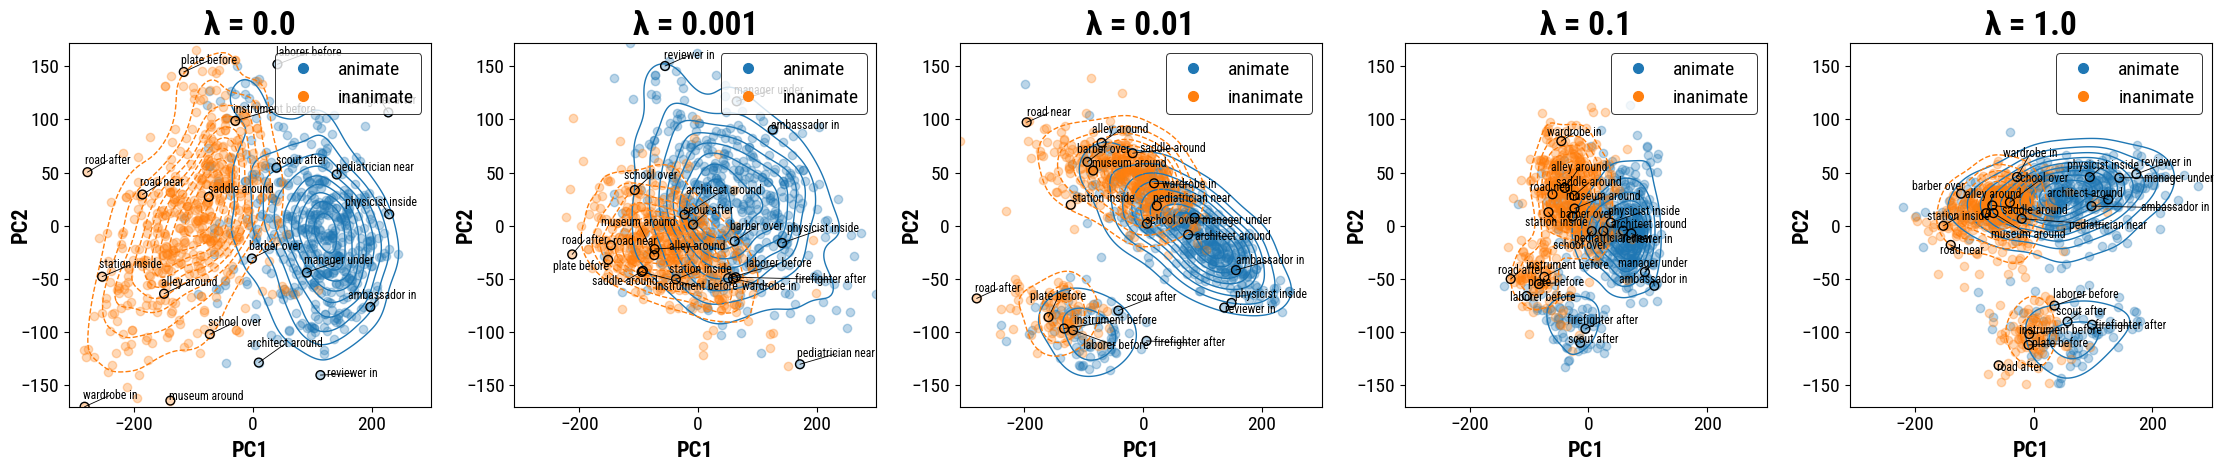

In [8]:
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 24,
    'axes.labelweight': 'bold',
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "font.family": "Roboto Condensed",
    "mathtext.fontset": "custom",        
    "mathtext.rm": "Roboto Condensed",   
    "mathtext.it": "Roboto Condensed:italic",
    "mathtext.bf": "Roboto Condensed:bold",
})

panel_titles = {
    'lambda0p0': "λ = 0.0",
    'lambda0p001': "λ = 0.001",
    'lambda0p01': "λ = 0.01",
    'lambda0p1': "λ = 0.1",
    'lambda1p0': "λ = 1.0"
}


#### plotting

n_models = len(model_names)
fig, axes = plt.subplots(1, n_models, figsize=(22.5, 5), squeeze=False)
fig.subplots_adjust(wspace=-0.09)

pc1_vals = []
pc2_vals = []

for model_name in model_names:
    X_pca = X_pca_dict[model_name]["X_pca"]
    pc1_vals.append(X_pca[:, 0])
    pc2_vals.append(X_pca[:, 1])

pc1_all = np.concatenate(pc1_vals)
pc2_all = np.concatenate(pc2_vals)

pc1_min, pc1_max = pc1_all.min(), pc1_all.max()
pc2_min, pc2_max = pc2_all.min(), pc2_all.max()

xx, yy = np.mgrid[pc1_min:pc1_max:200j, pc2_min:pc2_max:200j]

for ax, model_name in zip(axes[0], model_names):
    X_pca = X_pca_dict[model_name]["X_pca"]

    pca_ani = X_pca[:500, :]
    pca_inani = X_pca[500:, :]

    # First 500: Animate
    pc1_ani = X_pca[:500, 0]
    pc2_ani = X_pca[:500, 1]

    # Second 500: Inanimate
    pc1_inani = X_pca[500:, 0]
    pc2_inani = X_pca[500:, 1]

    ani_sc = ax.scatter(pc1_ani, pc2_ani, alpha=0.3, label="animate")
    inani_sc = ax.scatter(pc1_inani, pc2_inani, alpha=0.3, label="inanimate")

    # Add annotation for NP content
    pc1 = X_pca[:, 0]
    pc2 = X_pca[:, 1]
    ax.scatter(
        pc1[label_idx],
        pc2[label_idx],
        s=40,
        facecolors="none",
        edgecolors="black",
        linewidths=1.0,
        zorder=5
    )

    texts = []
    for i in label_idx:
        texts.append(
            ax.text(
                pc1[i], pc2[i],
                pretty_label(i),
                fontsize=8.5,
                ha="left", va="bottom",
                zorder=6
            )
        )

    adjust_text(
        texts, ax=ax,
        x=pc1[label_idx], y=pc2[label_idx],
        arrowprops=dict(arrowstyle="-", 
                        lw=0.6, 
                        alpha=1,
                        shrinkA=0,   
                        shrinkB=0),   
        lim=300,
        expand_text=(1.5, 2.5),
        expand_points=(1.5, 2.5),
        force_text=(0.6, 1),
        force_points=(0.6, 1),
        expand_axes=False,
        ensure_inside_axes=True
    )

    ani_kde = gaussian_kde(np.vstack([pc1_ani, pc2_ani]))
    zz_ani = ani_kde(np.vstack([xx.ravel(), yy.ravel()]))
    zz_ani = zz_ani.reshape(xx.shape)
    c_ani = tuple(ani_sc.get_facecolor()[0])  
    c_ani = (c_ani[0], c_ani[1], c_ani[2], 0.3) 
    ax.contour(xx, yy, zz_ani, levels=10, colors=[c_ani], linewidths=1.0, alpha=1.0)

    inani_kde = gaussian_kde(np.vstack([pc1_inani, pc2_inani]))
    zz_inani = inani_kde(np.vstack([xx.ravel(), yy.ravel()]))
    zz_inani = zz_inani.reshape(xx.shape)
    c_inani = tuple(inani_sc.get_facecolor()[0])
    c_inani = (c_inani[0], c_inani[1], c_inani[2], 0.3)
    ax.contour(xx, yy, zz_inani, levels=10, colors=[c_inani], linestyles="dashed", linewidths=1.0, alpha=1.0)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2", labelpad=-8)
    ax.set_title(panel_titles[model_name])

    ax.set_xlim(pc1_min, pc1_max)
    ax.set_ylim(pc2_min, pc2_max)

legend_ani = Line2D([0], [0], marker='o', markersize=7,
                    linestyle='none', color="#1f77b4", alpha=1.0,
                    label="animate")

legend_inani = Line2D([0], [0], marker='o', markersize=7,
                      linestyle='none', color="#ff7f0e", alpha=1.0,
                      label="inanimate")

for ax in axes[0]:
    leg = ax.legend(
        handles=[legend_ani, legend_inani],
        loc="upper right",
        frameon=True,
        fancybox=True
    )

    frame = leg.get_frame()
    frame.set_facecolor("white")   
    frame.set_alpha(0.8)           
    frame.set_edgecolor("black")
    frame.set_linewidth(0.7)

    leg.set_zorder(1000)

plt.tight_layout()
# plt.savefig("plots/PCA_NP.pdf", bbox_inches="tight", pad_inches=0.05)
plt.show()

### Silhouette scores

#### Silouette based on animacy feature

In [9]:
lambda_ordered_names = ["lambda0p0","lambda0p001","lambda0p01","lambda0p1","lambda1p0"]
y = np.array([0]*500 + [1]*500)

sil_animacy_means = []
sil_animacy_se = []          # SE over items (not pairwise distances)
sil_animacy_by_group = []    # (animate_mean, inanimate_mean)

for model_name in lambda_ordered_names:
    X = X_pca_dict[model_name]["X_pca"]   # shape (1000, 50)

    s_animacy_mean = silhouette_score(X, y, metric="euclidean")
    s_animacy_each = silhouette_samples(X, y, metric="euclidean")

    sil_animacy_means.append(float(s_animacy_mean))
    sil_animacy_se.append(float(s_animacy_each.std(ddof=1) / np.sqrt(len(s_animacy_each))))

    sil_animacy_by_group.append((float(s_animacy_each[:500].mean()), float(s_animacy_each[500:].mean())))

print("sil_animacy_means:", sil_animacy_means)
print("sil_animacy_se:", sil_animacy_se)
print("sil_animacy_by_group (ani, inani):", sil_animacy_by_group)

sil_animacy_means: [0.26414892077445984, 0.14347708225250244, 0.14341528713703156, 0.14479230344295502, 0.16836000978946686]
sil_animacy_se: [0.004482119345307227, 0.004651938085240319, 0.004808970376529507, 0.0035146375504116257, 0.0058474274459568085]
sil_animacy_by_group (ani, inani): [(0.26189130544662476, 0.26640650629997253), (0.07686115801334381, 0.21009299159049988), (0.10200069844722748, 0.18482983112335205), (0.10494702309370041, 0.18463756144046783), (0.06685923784971237, 0.2698608338832855)]


#### Silouette based on temporal-spatial preposition

In [10]:
df_NPs = pd.read_csv("noun_phrases.csv")
df_NPs["preposition"].unique()

array(['in', 'around', 'under', 'near', 'across', 'over', 'outside',
       'inside', 'before', 'after', 'behind', 'beside'], dtype=object)

In [11]:
mask_temporal = df_NPs["preposition"].isin(["before", "after"])
y = mask_temporal.astype(int).to_numpy()  # 1 is temporal prepositions ("before"/"after"), 0 is spatial prepositions

sil_prep_means = []
sil_prep_se = []          # SE over items (not pairwise distances)
sil_prep_by_group = []    # (animate_mean, inanimate_mean)

lambda_ordered_names = ["lambda0p0","lambda0p001","lambda0p01","lambda0p1","lambda1p0"]

for model_name in lambda_ordered_names:
    X = X_pca_dict[model_name]["X_pca"]   # shape (1000, 50)

    s_prep_mean = silhouette_score(X, y, metric="euclidean")
    s_prep_each = silhouette_samples(X, y, metric="euclidean")

    sil_prep_means.append(float(s_prep_mean))
    sil_prep_se.append(float(s_prep_each.std(ddof=1) / np.sqrt(len(s_prep_each))))

    sil_prep_by_group.append((
        float(s_prep_each[y == 1].mean()),   # temporal prepositions
        float(s_prep_each[y == 0].mean())    # spatial prepositions
    ))

print("sil_prep_means:", sil_prep_means)
print("sil_prep_se:", sil_prep_se)
print("sil_prep_by_group (temporal, spatial):", sil_prep_by_group)

sil_prep_means: [0.089104063808918, 0.14613421261310577, 0.2959749102592468, 0.21413041651248932, 0.21314139664173126]
sil_prep_se: [0.002376156148057537, 0.0036967715228970817, 0.005200385080533965, 0.0027148401221624915, 0.0036452018694471296]
sil_prep_by_group (temporal, spatial): [(0.1777016520500183, 0.07031064480543137), (0.26311179995536804, 0.12132079154253006), (0.5059718489646912, 0.25143012404441833), (0.34482431411743164, 0.18640747666358948), (0.3852938115596771, 0.17662423849105835)]


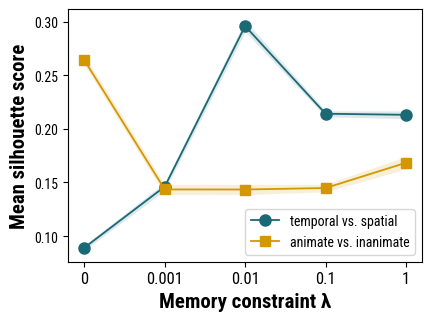

In [12]:
lambda_ordered_names = ["lambda0p0","lambda0p001","lambda0p01","lambda0p1","lambda1p0"]
lambda_labels = ["0", "0.001", "0.01", "0.1", "1"]

x_pos = np.arange(len(lambda_ordered_names))

prep_means = np.array(sil_prep_means, dtype=float)
prep_se = np.array(sil_prep_se, dtype=float)

ani_means = np.array(sil_animacy_means, dtype=float)
ani_se = np.array(sil_animacy_se, dtype=float)

y_lower = np.concatenate([prep_means - prep_se, ani_means - ani_se])
y_upper = np.concatenate([prep_means + prep_se, ani_means + ani_se])
y_min = np.nanmin(y_lower)
y_max = np.nanmax(y_upper)
y_range = y_max - y_min if y_max > y_min else 1.0
margin = 0.05 * y_range

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 15,
    "axes.labelweight": "bold",
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "Roboto Condensed"
})

fig, ax = plt.subplots(figsize=(4.6, 3.5))

# ---- temporal vs spatial ----
line_prep, = ax.plot(
    x_pos, prep_means,
    marker="o",
    markersize=8,
    linewidth=1.3,
    color="#1A6975",
    label="temporal vs. spatial"
)
prep_color = line_prep.get_color()

ax.fill_between(
    x_pos,
    prep_means - prep_se,
    prep_means + prep_se,
    color=prep_color,
    alpha=0.15,
    linewidth=0
)

# ---- animate vs inanimate ----
line_ani, = ax.plot(
    x_pos, ani_means,
    marker="s",
    markersize=7,
    linewidth=1.3,
    color="#D59701",
    label="animate vs. inanimate"
)
ani_color = line_ani.get_color()

ax.fill_between(
    x_pos,
    ani_means - ani_se,
    ani_means + ani_se,
    color=ani_color,
    alpha=0.15,
    linewidth=0
)

ax.axhline(0, linestyle="--", linewidth=1, alpha=0.6)

ax.set_ylabel("Mean silhouette score")
ax.set_xlabel("Memory constraint λ")

ax.set_xticks(x_pos)
ax.set_xticklabels(lambda_labels)

ax.set_ylim(y_min - margin, y_max + margin)

ax.legend(loc="best")

fig.tight_layout()
# plt.savefig(
#     "plots/silhouette_scores_animacy_prep_ACL.pdf",
#     bbox_inches="tight",
#     pad_inches=0.05
# )
plt.show()